### Introduction

You are a bird conservation expert and want to understand migration patterns of purple martins. In your research, you discover that these birds typically spend the summer breeding season in the eastern United States, and then migrate to South America for the winter. But since this bird is under threat of endangerment, you'd like to take a closer look at the locations that these birds are more likely to visit.

There are several protected areas in South America, which operate under special regulations to ensure that species that migrate (or live) there have the best opportunity to thrive. You'd like to know if purple martins tend to visit these areas. To answer this question, you'll use some recently collected data that tracks the year-round location of eleven different birds.

In [3]:
# Loading my data in csv format

import pandas as pd
birds_df = pd.read_csv(r"C:\Users\User pc\Documents\Geospatial_Data\purple_martin.csv")
birds_df

,timestamp,location-long,location-lat,tag-local-identifier
0,2014-08-15 05:56:00,-88.146014,17.513049,30448
1,2014-09-01 05:59:00,-85.243501,13.095782,30448
2,2014-10-30 23:58:00,-62.906089,-7.852436,30448
3,2014-11-15 04:59:00,-61.776826,-11.723898,30448
4,2014-11-30 09:59:00,-61.241538,-11.612237,30448
...,...,...,...,...
94,2014-12-30 19:59:00,-50.709645,-9.572583,30263
95,2015-01-14 23:59:00,-49.292113,-8.392265,30263
96,2015-01-30 03:59:00,-49.081317,-5.413250,30263
97,2015-02-14 07:59:00,-49.081245,-5.413251,30263


In [73]:
birds_df['tag-local-identifier'].unique()

array([30448, 30445, 30384, 30380, 30304, 30198, 30048, 30300, 30054,
       30275, 30263])

In [74]:
birds_df['tag-local-identifier'].value_counts()

tag-local-identifier
30448    10
30445    10
30380    10
30304    10
30048    10
30300    10
30275     9
30263     9
30054     8
30198     7
30384     6
Name: count, dtype: int64

In [100]:
#Converting my dataframe into a geodataframe and setting the CRS to EPSG:4326

import geopandas as gpd
birds_gdf = gpd.GeoDataFrame(birds_df, geometry = gpd.points_from_xy(birds_df['location-long'], birds_df['location-lat']))
birds_gdf.crs = {'init': 'epsg:4326'}
birds_gdf.head()

C:\Users\User pc\anaconda3\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,timestamp,location-long,location-lat,tag-local-identifier,geometry
0,2014-08-15 05:56:00,-88.146014,17.513049,30448,POINT (-88.14601 17.51305)
1,2014-09-01 05:59:00,-85.243501,13.095782,30448,POINT (-85.2435 13.09578)
2,2014-10-30 23:58:00,-62.906089,-7.852436,30448,POINT (-62.90609 -7.85244)
3,2014-11-15 04:59:00,-61.776826,-11.723898,30448,POINT (-61.77683 -11.7239)
4,2014-11-30 09:59:00,-61.241538,-11.612237,30448,POINT (-61.24154 -11.61224)


In [55]:
# Next, we load in the 'naturalearth_lowres' dataset from GeoPandas, and set americas to a GeoDataFrame containing the boundaries of all countries
# in the Americas (both North and South America).

world = gpd.read_file(r"C:\Users\User pc\Desktop\Python_Geospatial_Analysis\New folder\ne_110m_admin_0_countries.shp")
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


### Listing and checking out hidden columns in very large datasets (CONTINENET column for this analysis)

The dataset world above as we can see has 177 rows and 169 columns, but we cannot see all the columns and many or some of the columns we need for analysis are hidden and in order for us to see the full column names we run either of this set of codes

In [78]:
print(world.columns.tolist(), sep = ' ')
# The sep = ' ' is just to print then from left to right line by line to save space instead of it being printed vertically down

['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'AD

In [81]:
for i in world.columns:
    print (i, end = ' , ')

featurecla , scalerank , LABELRANK , SOVEREIGNT , SOV_A3 , ADM0_DIF , LEVEL , TYPE , TLC , ADMIN , ADM0_A3 , GEOU_DIF , GEOUNIT , GU_A3 , SU_DIF , SUBUNIT , SU_A3 , BRK_DIFF , NAME , NAME_LONG , BRK_A3 , BRK_NAME , BRK_GROUP , ABBREV , POSTAL , FORMAL_EN , FORMAL_FR , NAME_CIAWF , NOTE_ADM0 , NOTE_BRK , NAME_SORT , NAME_ALT , MAPCOLOR7 , MAPCOLOR8 , MAPCOLOR9 , MAPCOLOR13 , POP_EST , POP_RANK , POP_YEAR , GDP_MD , GDP_YEAR , ECONOMY , INCOME_GRP , FIPS_10 , ISO_A2 , ISO_A2_EH , ISO_A3 , ISO_A3_EH , ISO_N3 , ISO_N3_EH , UN_A3 , WB_A2 , WB_A3 , WOE_ID , WOE_ID_EH , WOE_NOTE , ADM0_ISO , ADM0_DIFF , ADM0_TLC , ADM0_A3_US , ADM0_A3_FR , ADM0_A3_RU , ADM0_A3_ES , ADM0_A3_CN , ADM0_A3_TW , ADM0_A3_IN , ADM0_A3_NP , ADM0_A3_PK , ADM0_A3_DE , ADM0_A3_GB , ADM0_A3_BR , ADM0_A3_IL , ADM0_A3_PS , ADM0_A3_SA , ADM0_A3_EG , ADM0_A3_MA , ADM0_A3_PT , ADM0_A3_AR , ADM0_A3_JP , ADM0_A3_KO , ADM0_A3_VN , ADM0_A3_TR , ADM0_A3_ID , ADM0_A3_PL , ADM0_A3_GR , ADM0_A3_IT , ADM0_A3_NL , ADM0_A3_SE , ADM0_A3_

In [51]:
print([i for i in world.columns if 'Continent' in i.lower() or 'cont' in i.lower()])

['CONTINENT']


In [75]:
americas = world.loc[world['CONTINENT'].isin(['North America', 'South America'])]
americas.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
9,Admin-0 country,1,2,Argentina,ARG,0,2,Sovereign country,1,Argentina,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-68.63401 -52.63637, -68.25 -5..."
10,Admin-0 country,1,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-68.63401 -52.63637, -68.63335..."
16,Admin-0 country,1,5,Haiti,HTI,0,2,Sovereign country,1,Haiti,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-71.71236 19.71446, -71.62487 19.169..."


<Axes: >

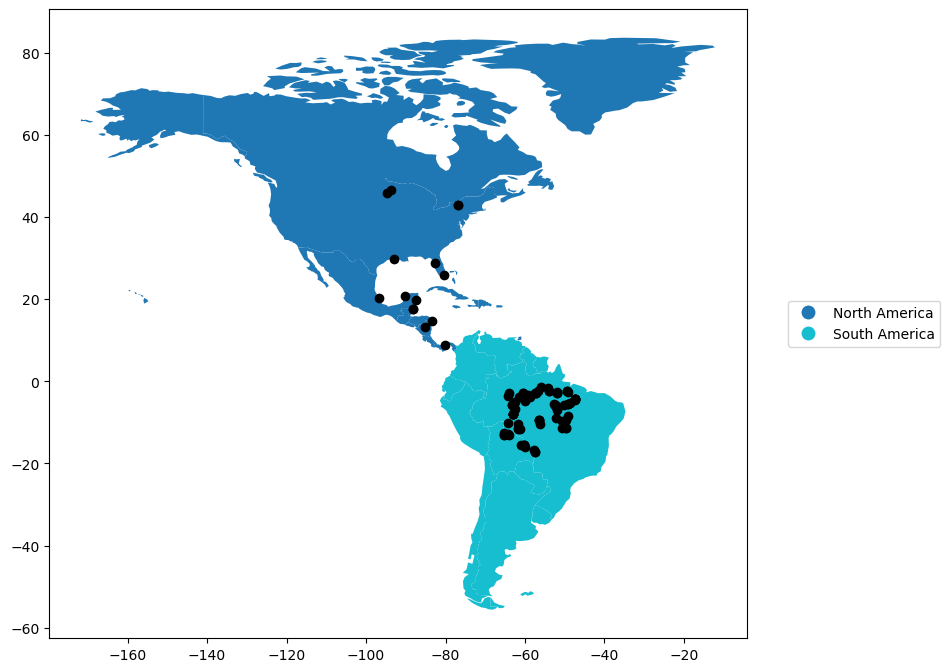

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (9, 14))
americas.plot(ax = ax, column = 'CONTINENT', legend = True, legend_kwds = {'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)})
birds_gdf.plot(ax=ax, color = 'black')

### Creating the Flight Paths (Points to Lines)

Taking the raw GPS tracking points from the the birds dataframe and transform them into meaningful spatial data structures for tracking wildlife movement. each bird has a tag identifier and as they move their locations (Long & Lat) are recorded at different points and time so combining each points and connecting them to create a flight path

In [11]:
from shapely.geometry import LineString
path_df = birds_gdf.groupby("tag-local-identifier")['geometry'].apply(list).apply(lambda x: LineString(x)).reset_index()
path_gdf = gpd.GeoDataFrame(path_df, geometry=path_df.geometry)
path_gdf.crs  = 'EPSG:4326'

### Extracting the Starting Points

In [9]:
start_df = birds_gdf.groupby("tag-local-identifier")['geometry'].apply(list).apply(lambda x: x[0]).reset_index()
start_gdf = gpd.GeoDataFrame(start_df, geometry=start_df.geometry)
start_gdf.crs = 'EPSG:4326'

### Extracting the Final Destination

In [10]:
end_df = birds_gdf.groupby("tag-local-identifier")['geometry'].apply(list).apply(lambda x: x[-1]).reset_index()
end_gdf = gpd.GeoDataFrame(end_df, geometry=end_df.geometry)
end_gdf.crs = 'EPSG:4326'

<Axes: >

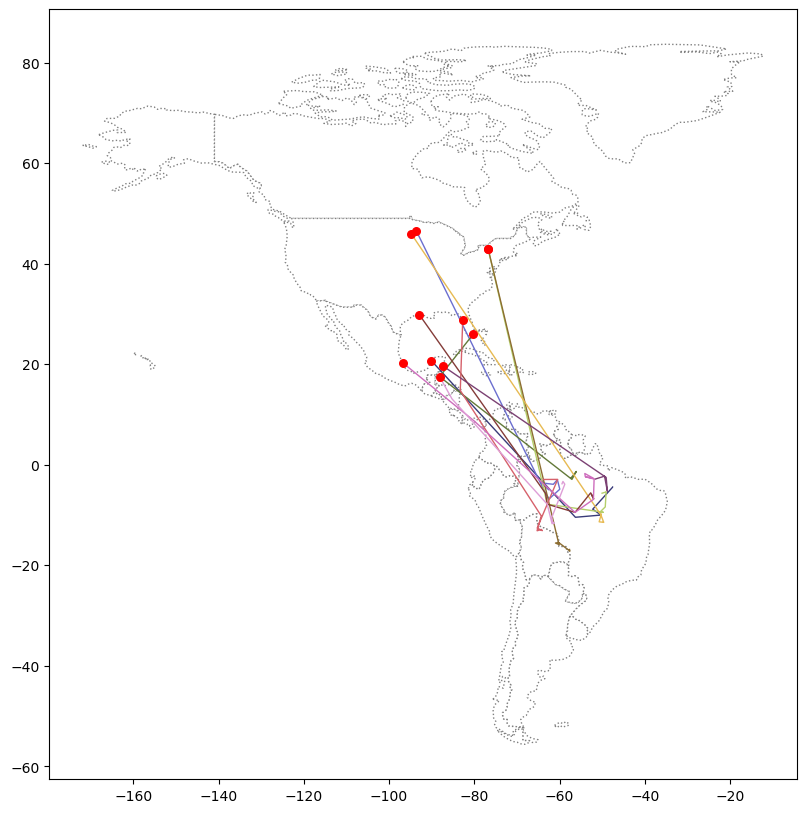

In [104]:
ax = americas.plot(figsize=(10, 10), color='white', linestyle=':', edgecolor='gray')

path_gdf.plot(ax=ax, cmap='tab20b', linestyle='-', linewidth=1, zorder=1)
start_gdf.plot(ax=ax, color='red',  markersize=30)


### Visualizing the Paths of all the Birds, the Start Points and End Points

<Axes: >

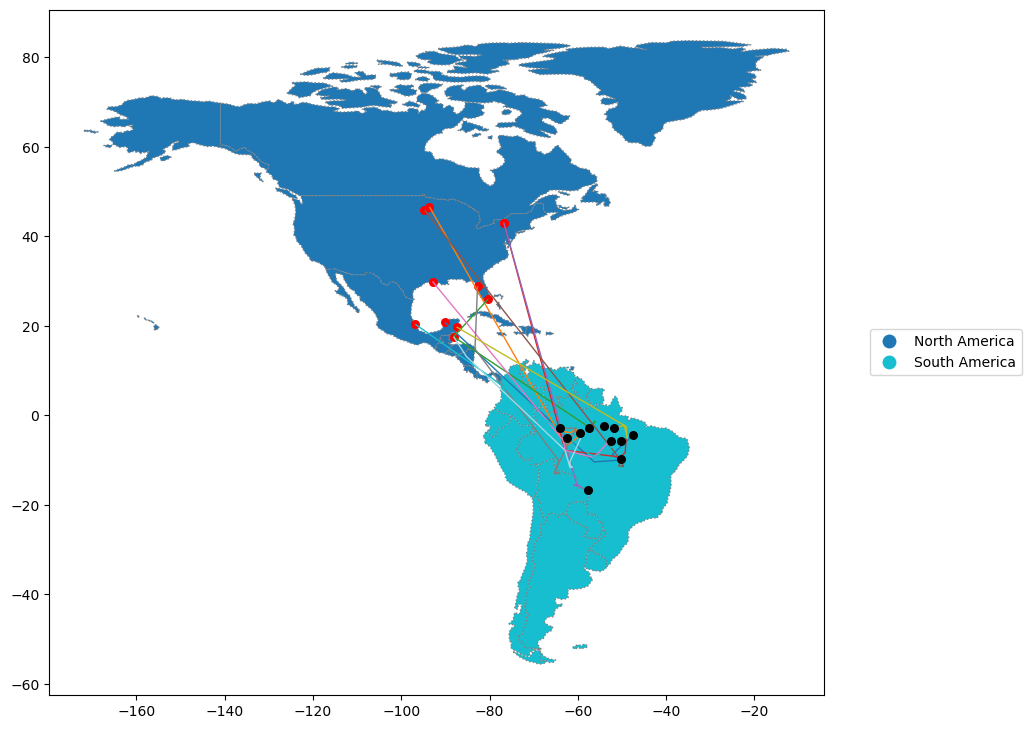

In [19]:
ax = americas.plot(figsize=(10, 10), linestyle=':', edgecolor='gray', column = 'CONTINENT', legend = True, legend_kwds = {'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)})

start_gdf.plot(ax=ax, color='red',  markersize=30)
path_gdf.plot(ax=ax, cmap='tab20', linestyle='-', linewidth=1, zorder=1)
end_gdf.plot(ax=ax, color='black', markersize=30)

In [21]:
protected_gdf = gpd.read_file(r"C:\Users\User pc\Documents\Geospatial_Data\SAPA_Aug2019-shapefile\SAPA_Aug2019-shapefile\SAPA_Aug2019-shapefile-polygons.shp")
protected_gdf.head()

,WDPAID,WDPA_PID,PA_DEF,NAME,ORIG_NAME,DESIG,DESIG_ENG,DESIG_TYPE,IUCN_CAT,INT_CRIT,...,GOV_TYPE,OWN_TYPE,MANG_AUTH,MANG_PLAN,VERIF,METADATAID,SUB_LOC,PARENT_ISO,ISO3,geometry
0,14067.0,14067,1,Het Spaans Lagoen,Het Spaans Lagoen,"Ramsar Site, Wetland of International Importance","Ramsar Site, Wetland of International Importance",International,Not Reported,Not Reported,...,Not Reported,Not Reported,Not Reported,Management plan is not implemented and not ava...,State Verified,1856,Not Reported,NLD,ABW,"POLYGON ((-69.97523 12.47379, -69.97523 12.473..."
1,14003.0,14003,1,Bubali Pond Bird Sanctuary,Bubali Pond Bird Sanctuary,Bird Sanctuary,Bird Sanctuary,National,Not Reported,Not Applicable,...,Not Reported,Not Reported,Not Reported,Not Reported,State Verified,1899,Not Reported,NLD,ABW,"POLYGON ((-70.04734 12.56329, -70.04615 12.563..."
2,555624439.0,555624439,1,Arikok National Park,Arikok National Park,National Park,National Park,National,Not Reported,Not Applicable,...,Non-profit organisations,Non-profit organisations,Fundacion Parke Nacional Arikok,Not Reported,State Verified,1899,Not Reported,NLD,ABW,"MULTIPOLYGON (((-69.96302 12.48384, -69.96295 ..."
3,303894.0,303894,1,Madidi,Madidi,Area Natural de Manejo Integrado,Natural Integrated Management Area,National,Not Reported,Not Applicable,...,Federal or national ministry or agency,Not Reported,Not Reported,Not Reported,State Verified,1860,BO-L,BOL,BOL,"POLYGON ((-68.5906 -14.43388, -68.59062 -14.43..."
4,303893.0,303893,1,Apolobamba,Apolobamba,Area Natural de Manejo Integado Nacional,National Natural Integrated Management Area,National,Not Reported,Not Applicable,...,Federal or national ministry or agency,Not Reported,Not Reported,Not Reported,State Verified,1860,BO-L,BOL,BOL,"POLYGON ((-69.20949 -14.73334, -69.2013 -14.73..."


In [22]:
protected_gdf.columns

Index(['WDPAID', 'WDPA_PID', 'PA_DEF', 'NAME', 'ORIG_NAME', 'DESIG',
       'DESIG_ENG', 'DESIG_TYPE', 'IUCN_CAT', 'INT_CRIT', 'MARINE',
       'REP_M_AREA', 'GIS_M_AREA', 'REP_AREA', 'GIS_AREA', 'NO_TAKE',
       'NO_TK_AREA', 'STATUS', 'STATUS_YR', 'GOV_TYPE', 'OWN_TYPE',
       'MANG_AUTH', 'MANG_PLAN', 'VERIF', 'METADATAID', 'SUB_LOC',
       'PARENT_ISO', 'ISO3', 'geometry'],
      dtype='object')

### Loading all the records of regions in America shapefile that falls under the south America Continent

As we can see in the earlier plot that all the birds took off from north america and landed at various places in the south american continent. So we are going to load the records of every country in the south american continent to see where exactly the birds landed and if they are also in the protected areas

In [38]:
south_america = americas.loc[americas['CONTINENT']=='South America']
south_america.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
9,Admin-0 country,1,2,Argentina,ARG,0,2,Sovereign country,1,Argentina,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-68.63401 -52.63637, -68.25 -5..."
10,Admin-0 country,1,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-68.63401 -52.63637, -68.63335..."
20,Admin-0 country,1,5,United Kingdom,GB1,1,2,Disputed,1,Falkland Islands,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-61.2 -51.85, -60 -51.25, -59.15 -51..."
28,Admin-0 country,1,4,Uruguay,URY,0,2,Sovereign country,1,Uruguay,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-57.62513 -30.21629, -56.97603 -30.1..."
29,Admin-0 country,1,2,Brazil,BRA,0,2,Sovereign country,1,Brazil,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-53.37366 -33.76838, -53.65054 -33.2..."


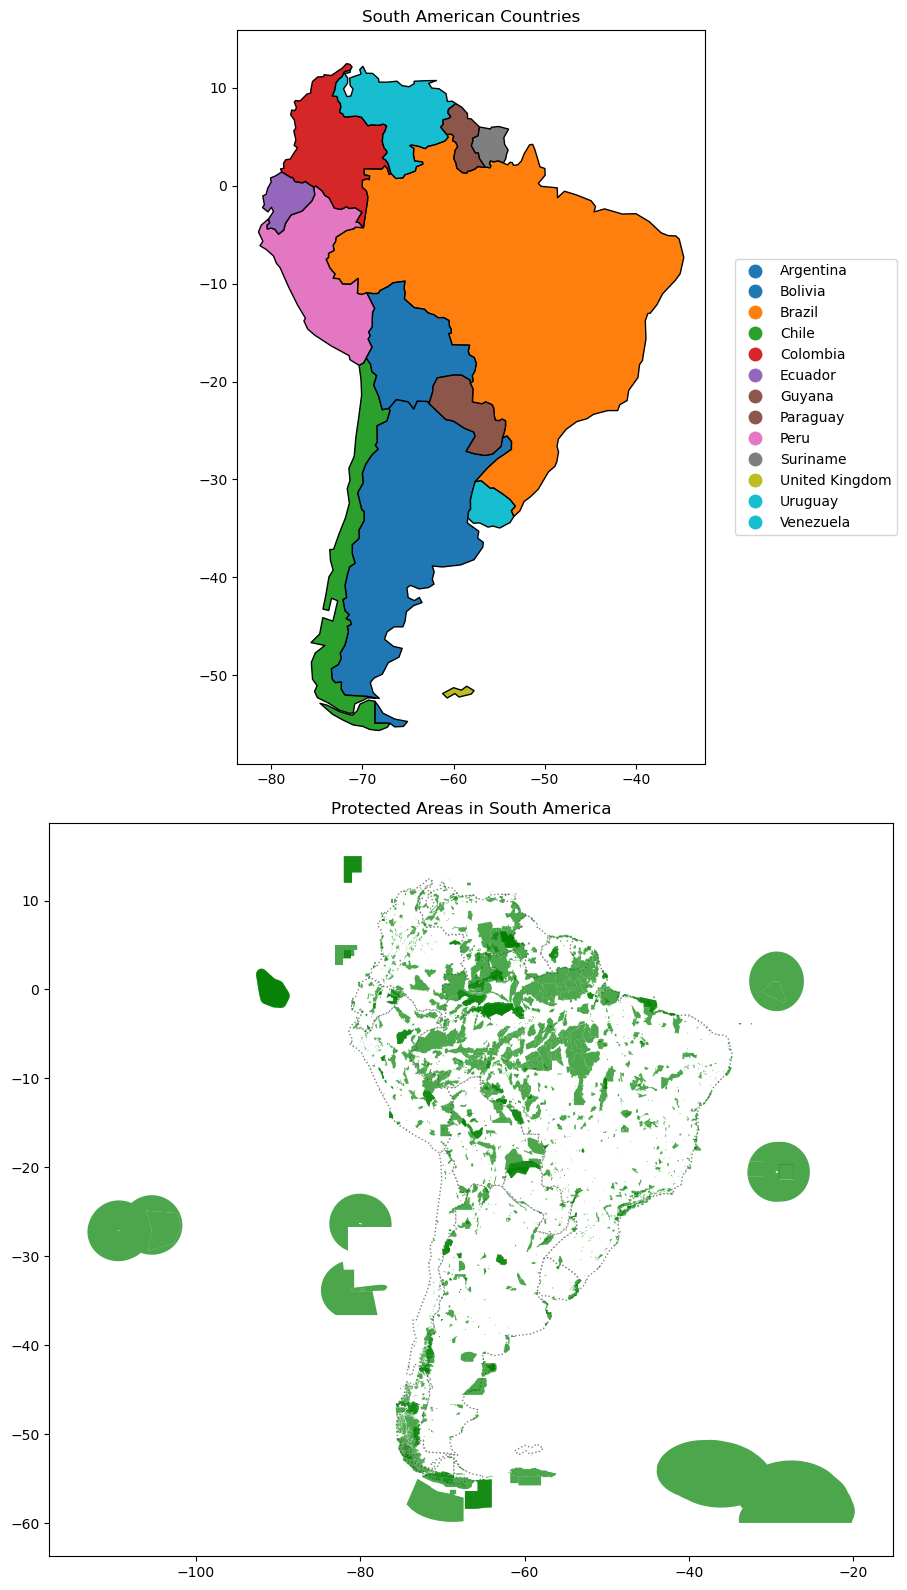

In [37]:
# 1. Create a 2-row grid layout. Adjust figsize here to give both maps room.
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 16))

# 2. First Plot: Base Map of South America Countries
south_america.plot(
    ax=ax1, 
    column='SOVEREIGNT', 
    edgecolor='black', 
    legend=True, 
    legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)}
)
ax1.set_title("South American Countries", fontsize=12)

# 3. Second Plot: Base Map Layer (Forced onto ax2)
south_america.plot(
    ax=ax2, 
    color='white', 
    linestyle=':', 
    edgecolor='gray'
)

# 4. Overlay: Protected Areas Layer (Forced onto ax2 as well)
protected_gdf.plot(
    ax=ax2, 
    color='green', 
    alpha=0.7  # Added transparency so you can see country borders underneath
)
ax2.set_title("Protected Areas in South America", fontsize=12)

plt.tight_layout() # Adjusts spacing so titles and plots don't overlap
plt.show()

### Calculating the percentage of South America that is protected

As we can see from the map above that some protected area fall into marine bodies outside the south american continent land boundaries, so we want to know the area and percentage of south america that is protected

In [43]:
protected_gdf.loc[:, ['REP_AREA', 'REP_M_AREA']]

,REP_AREA,REP_M_AREA
0,0.700000,0.0
1,0.200000,0.0
2,34.000000,0.0
3,6035.113401,0.0
4,4737.960587,0.0
...,...,...
4743,113.770000,0.0
4744,75.000000,0.0
4745,33.890000,0.0
4746,10.000000,0.0


### Calculating the Total Area of Protected Areas 

In [47]:
P_Area = sum(protected_gdf['REP_AREA']-protected_gdf['REP_M_AREA'])
print("South America has {} square kilometers of protected areas.".format(P_Area))

South America has 5396761.911688372 square kilometers of protected areas.


In [50]:
P_Area = str(sum(protected_gdf['REP_AREA']-protected_gdf['REP_M_AREA']))
print('South America has', P_Area, 'square kilometers of protected areas.')

South America has 5396761.911688372 square kilometers of protected areas.


### Calculating the Total Area of South America

In our earlier south ameria geodataframe, our crs is epsg:4326 which is a geographical coordinate system which uses a three-dimensional spherical surface to define locations on the Earth. Coordinates are measured in degrees (Latitude and Longitude). Units is in Decimal Degrees (e.g., 40.7128, -74.0060) so we cannot use this to accurately calculate distances or areas (like calculating the square miles).

So what we do is we convert the crs from geographic coordinate systems to projected coordinate system of the particular region of interest which flattens the earth's surface into a 2D plane. Coordinates are measured in linear units like meters or feet, making them perfect for doing math.

In [51]:
south_america_projected = south_america.to_crs("EPSG:5641")

### Calculating the Total Area of South America

Now that we have reprojected our coordinate systems, we can now calculate the area of each country in the south american continent. In the projected shapefile, the crs is meter based and the default unit of calculating area is (Km^2 which is 1,000,000 meters)

In [59]:
Area_of_each_south_american_country = south_america_projected.geometry.area / 10**6 
total_area = str(sum(Area_of_each_south_american_country))
print ('The total area of South America is', total_area, 'Kilometers Square')
    

The total area of South America is 20723775.183834627 Kilometers Square


### Calculating the percentage of South America that is protected

So the total protected areas in south america is 5396761.911688372 square kilometers and the total areas in south america is 20723775.183834627 Kilometers square


In [67]:
protected_area = 5396761.911688372
total_area = 20723775.183834627
percentage_protected = (protected_area / total_area) * 100
print ( f'The approximate % of protected areas in South America is{percentage_protected: .2f}%') 

The approximate % of protected areas in South America is 26.04%


### Where the birds are in South America
So, are the birds in protected areas?

Creating a plot that shows for all birds, all of the locations where they were discovered in South America, and also plotting the locations of all protected areas in South America.

To exclude protected areas that are purely marine areas (with no land component),used the "MARINE" column (and plot only the rows in protected_areas, instead of every row in the protected_areas GeoDataFrame). '2' is a text string code used by global environmental databases (like the World Database on Protected Areas). In their classification system, a code of '2' stands for Purely Marine Protected Areas (open ocean sanctuaries with zero land component).


In [64]:
protected_gdf.columns

Index(['WDPAID', 'WDPA_PID', 'PA_DEF', 'NAME', 'ORIG_NAME', 'DESIG',
       'DESIG_ENG', 'DESIG_TYPE', 'IUCN_CAT', 'INT_CRIT', 'MARINE',
       'REP_M_AREA', 'GIS_M_AREA', 'REP_AREA', 'GIS_AREA', 'NO_TAKE',
       'NO_TK_AREA', 'STATUS', 'STATUS_YR', 'GOV_TYPE', 'OWN_TYPE',
       'MANG_AUTH', 'MANG_PLAN', 'VERIF', 'METADATAID', 'SUB_LOC',
       'PARENT_ISO', 'ISO3', 'geometry'],
      dtype='object')

In [65]:
protected_gdf['MARINE']

0       1
1       2
2       1
3       0
4       0
       ..
4743    0
4744    0
4745    0
4746    0
4747    0
Name: MARINE, Length: 4748, dtype: object

In [77]:
not_marine = protected_gdf.loc[protected_gdf['MARINE'] != '2']
not_marine['MARINE']

0       1
2       1
3       0
4       0
5       0
       ..
4743    0
4744    0
4745    0
4746    0
4747    0
Name: MARINE, Length: 4634, dtype: object

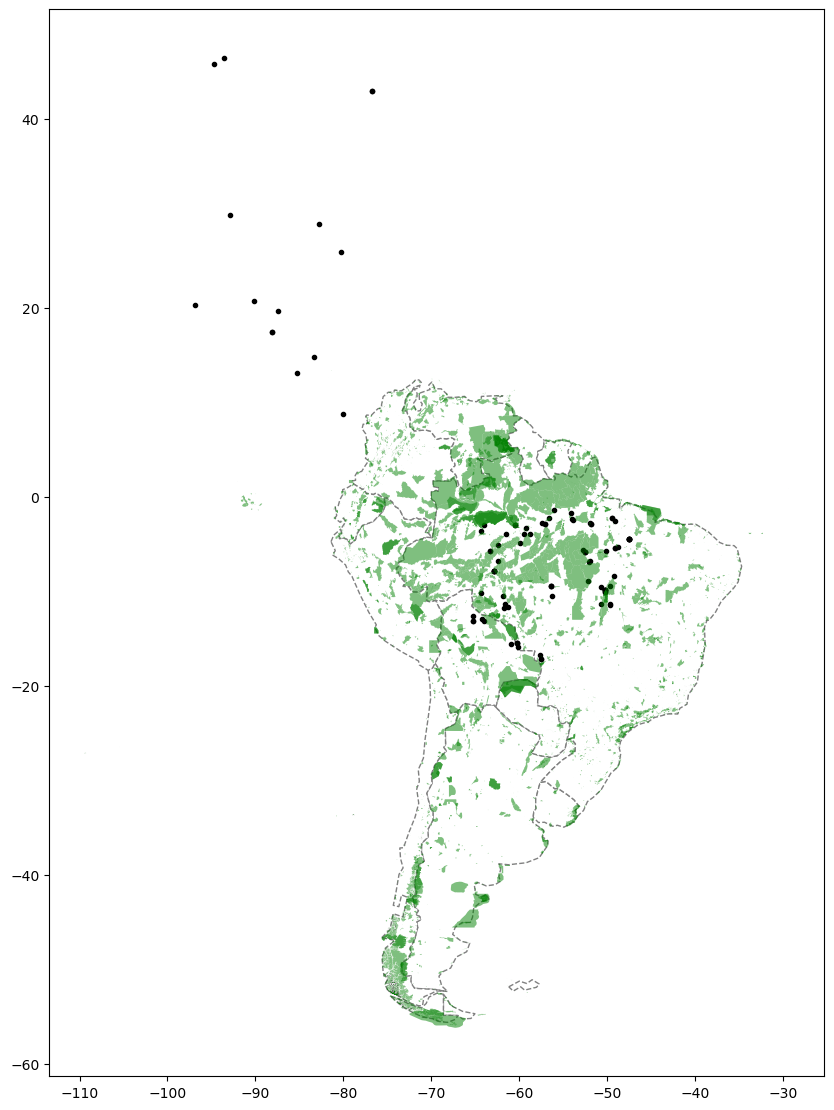

In [98]:
fig, ax = plt.subplots(figsize = (10,16))
south_america.plot(ax=ax, linestyle = '--', linewidth = 1, edgecolor = 'grey', color = 'white')
birds_gdf.plot (ax = ax, color = 'black', markersize = 9)
not_marine.plot(ax = ax, color = 'green', alpha = 0.5)
plt.tight_layout
plt.show()

### Filtering the map

birds[birds.geometry.y < 0]: This is a spatial filter! In coordinate geometry, geometry.y represents Latitude. Because the Equator is at $0^\circ$ latitude, everything below the Equator (South) has a negative coordinate ($< 0$). This line filters your bird dataset to only plot tracking points located in the Southern Hemisphere.

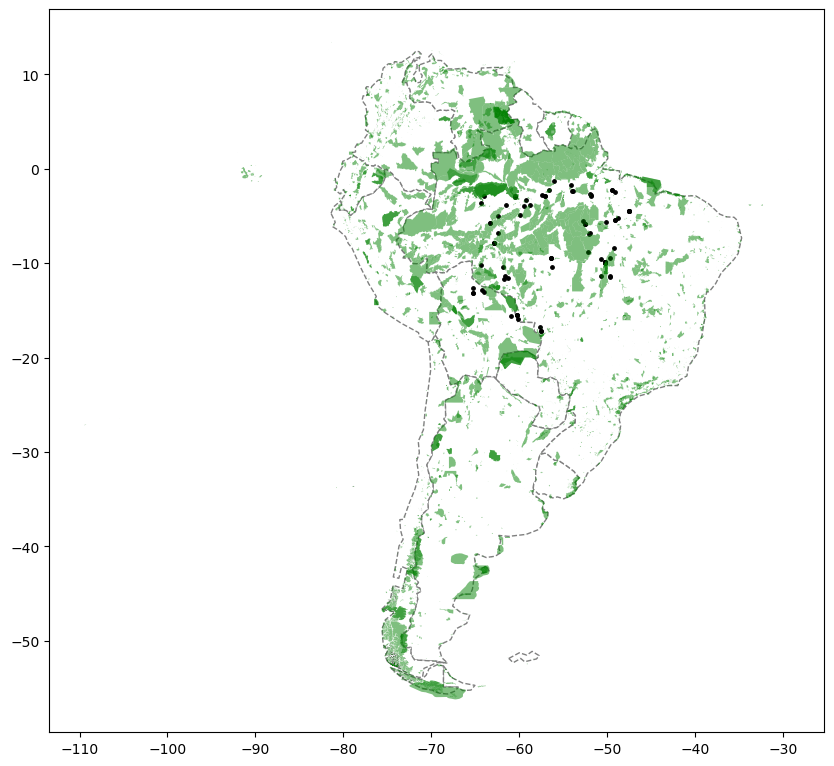

In [97]:
fig, ax = plt.subplots(figsize = (10,16))
south_america.plot(ax=ax, linestyle = '--', linewidth = 1, edgecolor = 'grey', color = 'white')
birds_gdf[birds_gdf.geometry.y < 0].plot (ax = ax, color = 'black', markersize = 9)
not_marine.plot(ax = ax, color = 'green', alpha = 0.5)
plt.tight_layout
plt.show()

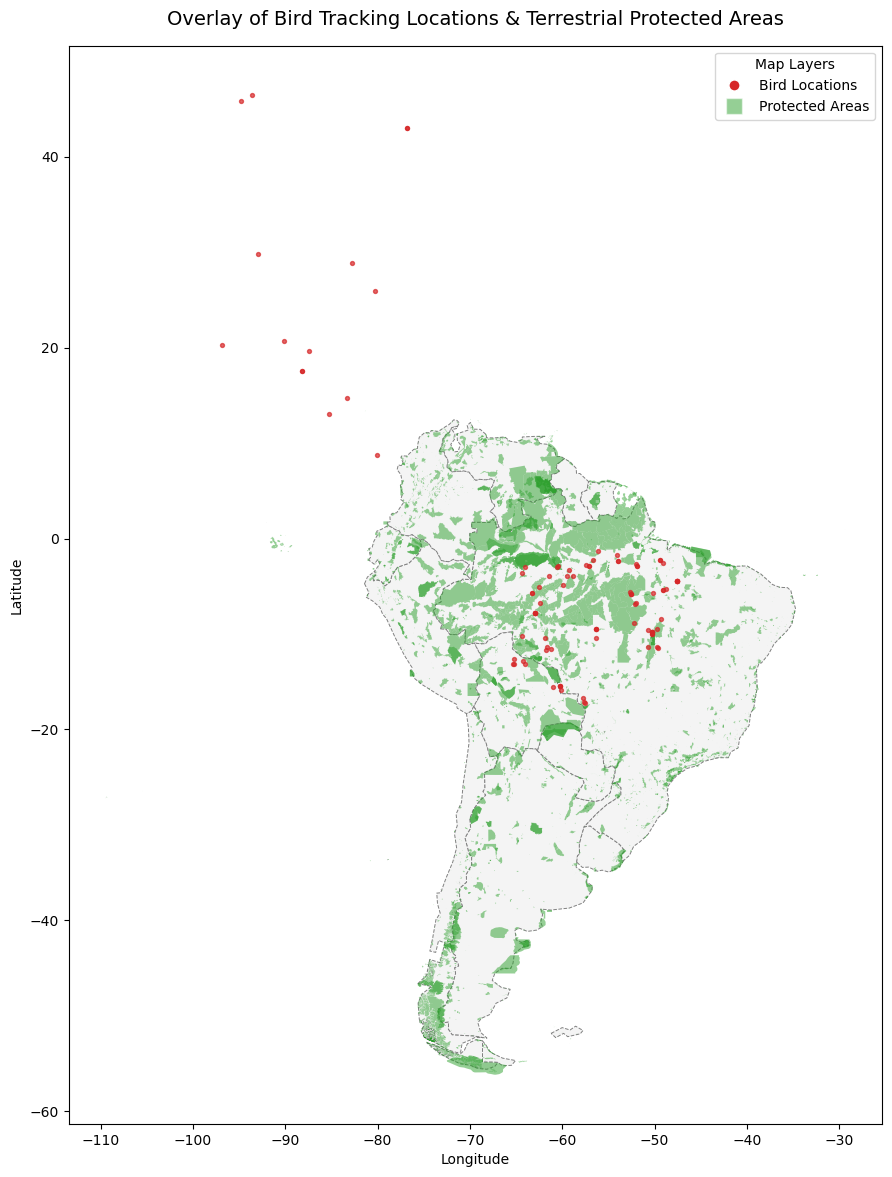

In [95]:
# 1. Filter protected areas to exclude purely marine zones ('2' = Marine)
terrestrial_protected= protected_gdf[protected_gdf['MARINE'] != '2']

# 2. Set up the map canvas size
fig, ax = plt.subplots(figsize=(12, 14))

# 3. Plot Layer 1: South America Continent Outline (Base)
south_america.plot(
    ax=ax, 
    color='#f4f4f4', 
    edgecolor='gray', 
    linestyle='--', 
    linewidth=0.7
)

# 4. Plot Layer 2: Terrestrial Protected Areas (Green)
terrestrial_protected.plot(
    ax=ax, 
    color='#2ca02c', 
    alpha=0.5, 
    label='Protected Areas'
)

# 5. Plot Layer 3: Bird Discovery Locations (Points)
# Adjust 'markersize' if the dots look too big or too small on your screen
birds_gdf.plot(
    ax=ax, 
    color='#d62728', 
    markersize=8, 
    alpha=0.7, 
    marker='o', 
    label='Bird Tracking Points'
)

# 6. Customize Map Design & Labels
ax.set_title("Overlay of Bird Tracking Locations & Terrestrial Protected Areas", fontsize=14, pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Create a clean map legend manually using Matplotlib's proxy artists
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Bird Locations', markerfacecolor='#d62728', markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Protected Areas', markerfacecolor='#2ca02c', markersize=12, alpha=0.5)
]
ax.legend(handles=legend_elements, loc='upper right', title="Map Layers")

# Remove background grid lines for a cleaner look
ax.grid(False)

plt.show()